## Heart Disease Prediction 


## Farah Abu-Shariha - 60104384

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# loading the dataset
# source : UCI Heart Disease Dataset (cleveland , hungary , switzerland , virginia)
df = pd.read_csv('heart_disease_uci.csv')

# if the url doesnt work load it localy: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
# df = pd.read_csv('heart_disease_uci.csv')

print(df.shape)
df.head()

(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [39]:
# checking basic info
print(df.info())
print()


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None



In [40]:
print('missing values:')
print(df.isnull().sum())

missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [41]:
# checking the target column
# target : 0 = no heart disease , 1 = has heart disease
print(df['num'].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [42]:
# we convert it to binary : 0 = no disease , 1 = has disease
df['target'] = (df['num'] > 0).astype(int)
print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


## exploratory data analysis

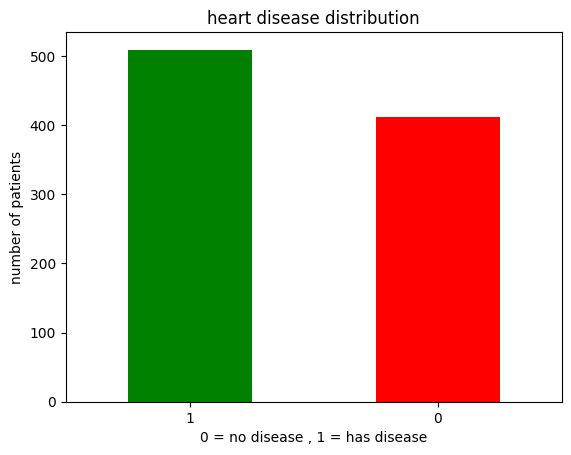

no disease: 411
has disease: 509


In [43]:
# visualizing target distribution
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('heart disease distribution')
plt.xlabel('0 = no disease , 1 = has disease')
plt.ylabel('number of patients')
plt.xticks(rotation=0)
plt.show()
print('no disease:', df['target'].value_counts()[0])
print('has disease:', df['target'].value_counts()[1])

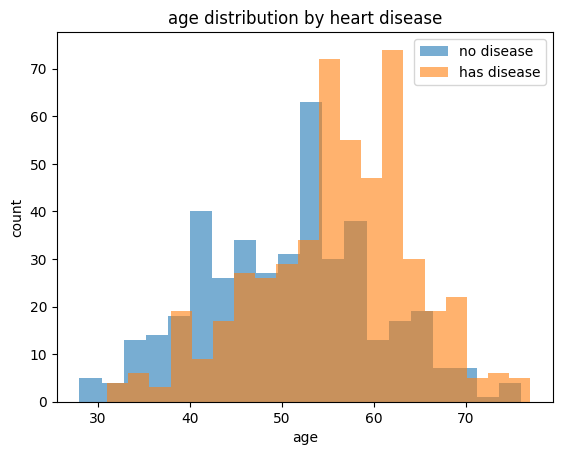

In [44]:
# checking age distribution by target
df.groupby('target')['age'].plot(kind='hist', alpha=0.6, bins=20, legend=True)
plt.title('age distribution by heart disease')
plt.xlabel('age')
plt.ylabel('count')
plt.legend(['no disease', 'has disease'])
plt.show()

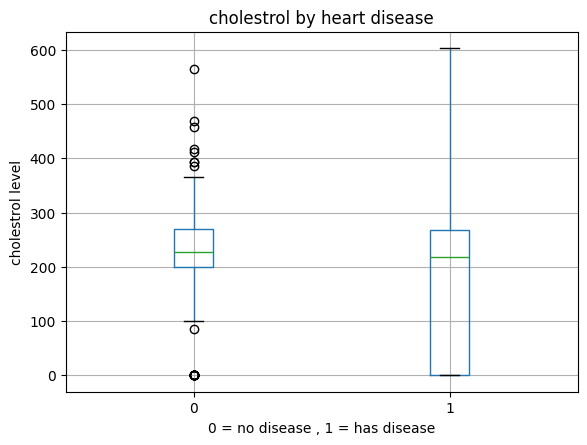

In [45]:
# checking cholestrol vs target
df.boxplot(column='chol', by='target')
plt.title('cholestrol by heart disease')
plt.suptitle('')
plt.xlabel('0 = no disease , 1 = has disease')
plt.ylabel('cholestrol level')
plt.show()

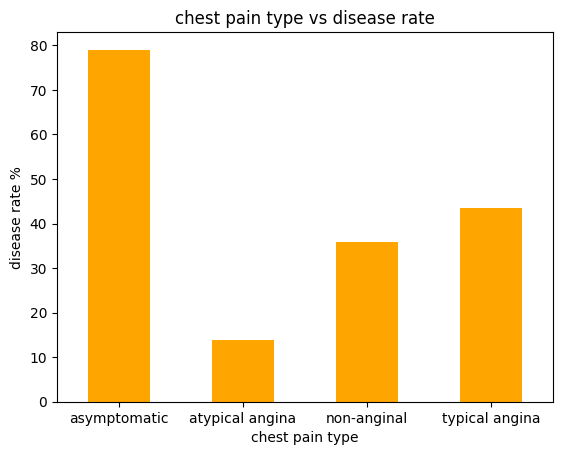

In [46]:
# checking how chest pain type affects heart disease
df.groupby('cp')['target'].mean().mul(100).plot(kind='bar', color='orange')
plt.title('chest pain type vs disease rate')
plt.xlabel('chest pain type')
plt.ylabel('disease rate %')
plt.xticks(rotation=0)
plt.show()

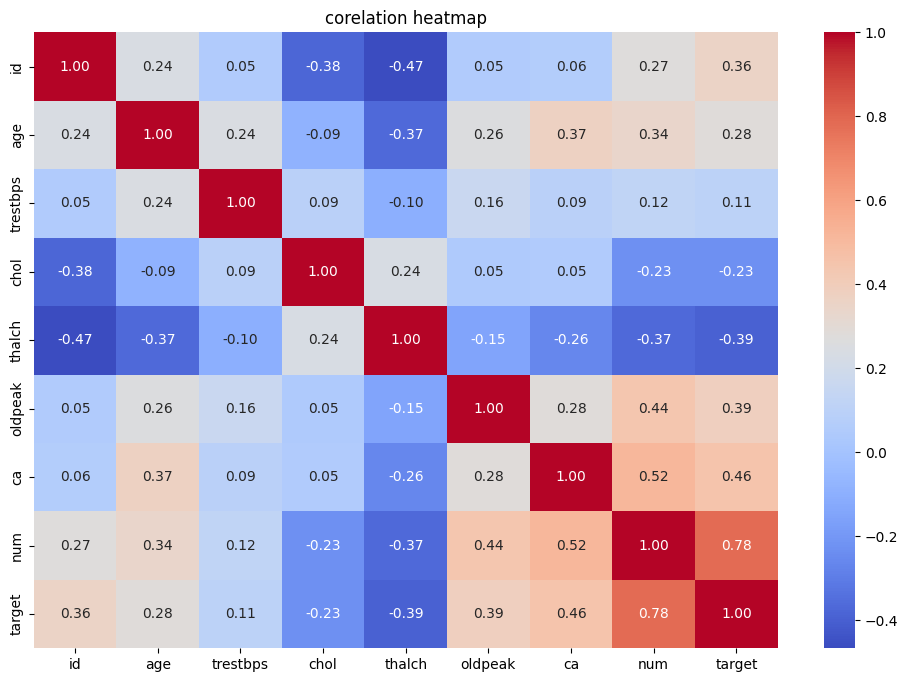

In [47]:
# corelation heatmap to see which features are related to target
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('corelation heatmap')
plt.show()

## preprocessing

In [48]:
# selecting the features we will use
# dropping id , dataset (hospital name) , num (original target) and keeping our binary target
df2 = df.copy()

# dropping columns that are not useful
cols_to_drop = ['id', 'dataset', 'num']
df2 = df2.drop(columns=[c for c in cols_to_drop if c in df2.columns])

print('columns after drop:', list(df2.columns))

columns after drop: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [49]:
from sklearn.preprocessing import LabelEncoder

# encoding text columns
le = LabelEncoder()
for col in df2.select_dtypes(include='object').columns:
    df2[col] = le.fit_transform(df2[col].astype(str))

print('encoding done')
print(df2.dtypes)

encoding done
age           int64
sex           int32
cp            int32
trestbps    float64
chol        float64
fbs           int32
restecg       int32
thalch      float64
exang         int32
oldpeak     float64
slope         int32
ca          float64
thal          int32
target        int32
dtype: object


C:\Users\yasme\AppData\Local\Temp\ipykernel_12184\2372803874.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(include='object').columns:


In [50]:
# filling missing values with median
df2 = df2.fillna(df2.median())
print('missing values after filling:', df2.isnull().sum().sum())

missing values after filling: 0


In [51]:
# feature selection - selecting the most importnat features based on corelation with target
corr_with_target = numeric_df.corr()['target'].abs().sort_values(ascending=False)
print('feature corelation with target:')
print(corr_with_target)

feature corelation with target:
target      1.000000
num         0.783387
ca          0.455599
thalch      0.394503
oldpeak     0.385528
id          0.356086
age         0.282700
chol        0.230583
trestbps    0.106233
Name: target, dtype: float64


In [52]:
# selecting top features with corelation > 0.1
selected_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
# keeping only columns that exist in the dataset
selected_features = [f for f in selected_features if f in df2.columns]

X = df2[selected_features]
y = df2['target']

print('selected features:', selected_features)
print('X shape:', X.shape)
print('y shape:', y.shape)

selected features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X shape: (920, 13)
y shape: (920,)


In [53]:
from sklearn.model_selection import train_test_split

# spliting data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('training size:', len(X_train))
print('testing size:', len(X_test))

training size: 736
testing size: 184


## training the models

In [54]:
from sklearn.linear_model import LogisticRegression

# model 1 - logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('logistic regression')

logistic regression


In [55]:
from sklearn.ensemble import RandomForestClassifier

# model 2 - random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('random forest')

random forest


In [56]:
from sklearn.svm import SVC

# model 3 - support vector machine
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print('svm')

svm


## evaluating the models

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print('Logistic Regression accuracy :', round(lr_acc * 100, 2), '%')
print('Random Forest accuracy :', round(rf_acc * 100, 2), '%')
print('SVM accuracy :', round(svm_acc * 100, 2), '%')

Logistic Regression accuracy : 80.43 %
Random Forest accuracy : 84.24 %
SVM accuracy : 74.46 %


In [58]:
# clasification reports
print('logistic regression report')
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Has Disease']))

logistic regression report
              precision    recall  f1-score   support

  No Disease       0.79      0.76      0.78        82
 Has Disease       0.81      0.84      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



In [59]:
print('random forest report')
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Has Disease']))

random forest report
              precision    recall  f1-score   support

  No Disease       0.84      0.80      0.82        82
 Has Disease       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [60]:
print('svm report')
print(classification_report(y_test, svm_pred, target_names=['No Disease', 'Has Disease']))

svm report
              precision    recall  f1-score   support

  No Disease       0.73      0.67      0.70        82
 Has Disease       0.75      0.80      0.78       102

    accuracy                           0.74       184
   macro avg       0.74      0.74      0.74       184
weighted avg       0.74      0.74      0.74       184



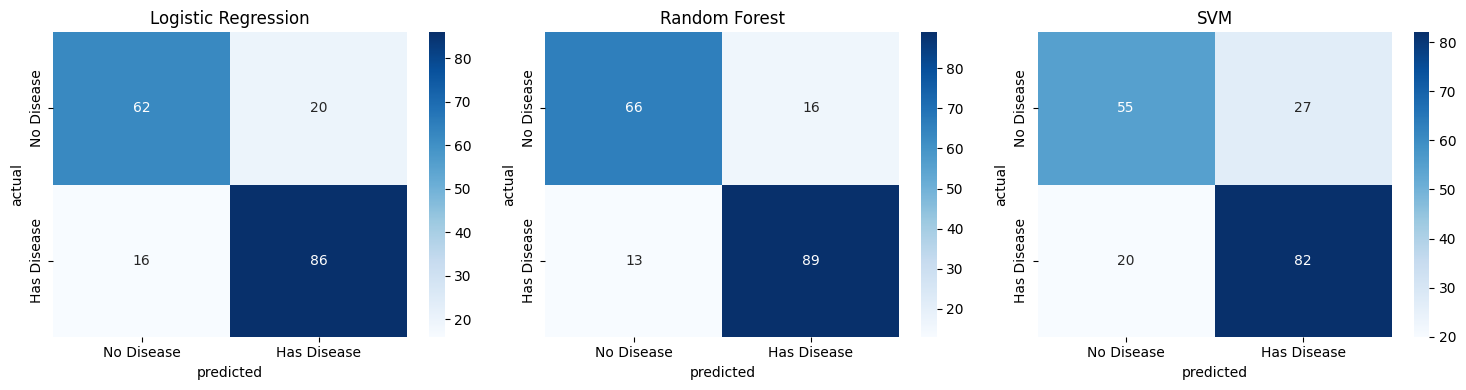

In [61]:
# confusion matrix for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pred, title in zip(axes,
                            [lr_pred, rf_pred, svm_pred],
                            ['Logistic Regression', 'Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Has Disease'],
                yticklabels=['No Disease', 'Has Disease'])
    ax.set_title(title)
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.tight_layout()
plt.show()

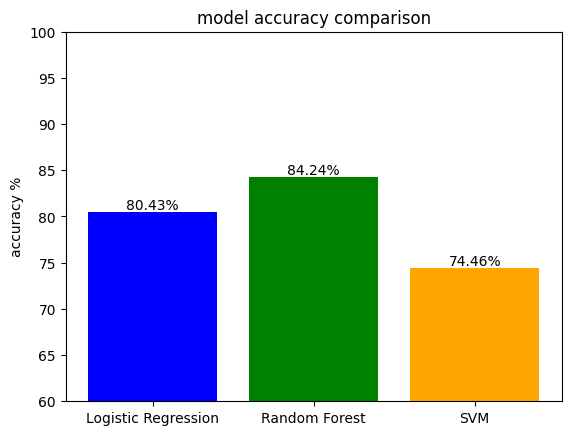

In [62]:
# comapring all models
models = ['Logistic Regression', 'Random Forest', 'SVM']
scores = [lr_acc * 100, rf_acc * 100, svm_acc * 100]

plt.bar(models, scores, color=['blue', 'green', 'orange'])
plt.ylim(60, 100)
plt.title('model accuracy comparison')
plt.ylabel('accuracy %')
for i, v in enumerate(scores):
    plt.text(i, v + 0.3, str(round(v, 2)) + '%', ha='center')
plt.show()

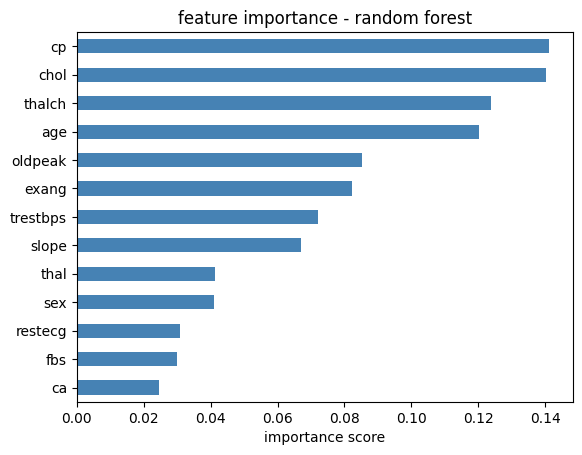

In [63]:
# feature importnace from random forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('feature importance - random forest')
plt.xlabel('importance score')
plt.show()

## cross validation

In [64]:
from sklearn.model_selection import cross_val_score

# cross validation using 5 folds to get a more relible accuracy estimate
# each fold is used for testing once while the rest are used for training
cv_lr  = cross_val_score(lr,  X, y, cv=5, scoring='accuracy')
cv_rf  = cross_val_score(rf,  X, y, cv=5, scoring='accuracy')
cv_svm = cross_val_score(svm, X, y, cv=5, scoring='accuracy')

print('logistic regression cv scores:', [round(s*100,1) for s in cv_lr])
print('average :', round(cv_lr.mean()*100, 2), '%')
print()
print('random forest cv scores:', [round(s*100,1) for s in cv_rf])
print('average :', round(cv_rf.mean()*100, 2), '%')
print()
print('svm cv scores:', [round(s*100,1) for s in cv_svm])
print('average :', round(cv_svm.mean()*100, 2), '%')


logistic regression cv scores: [77.7, 70.7, 89.1, 88.6, 65.2]
average : 78.26 %

random forest cv scores: [82.6, 70.7, 82.1, 82.1, 63.6]
average : 76.2 %

svm cv scores: [64.7, 57.6, 88.0, 75.0, 56.0]
average : 68.26 %


## hyperparameter tuning

In [65]:
from sklearn.model_selection import GridSearchCV

# hyperparameter tuning for random forest
# trying diffrent values to find the best settings
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('best parameters:', grid_search.best_params_)
print('best cv accuracy:', round(grid_search.best_score_*100, 2), '%')

# retraining with the best paramters found
rf_best = grid_search.best_estimator_
rf_best_acc = accuracy_score(y_test, rf_best.predict(X_test))
print('best rf test accuracy:', round(rf_best_acc*100, 2), '%')


best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
best cv accuracy: 82.47 %
best rf test accuracy: 84.24 %


## saving and loading the model

In [66]:
import joblib

# saving the best model 
joblib.dump(rf_best, 'heart_disease_model.pkl')
print('model saved as heart_disease_model.pkl')

# loading the saved model
loaded_model = joblib.load('heart_disease_model.pkl')
print('model loaded succesfully')

# checking the loaded model still works
loaded_acc = accuracy_score(y_test, loaded_model.predict(X_test))
print('loaded model accuracy:', round(loaded_acc*100, 2), '%')


model saved as heart_disease_model.pkl
model loaded succesfully
loaded model accuracy: 84.24 %


## demo - predicting for new patients

In [67]:
if 'rf_best' not in dir():
    print("Warning: rf_best not found. Using rf instead.")
    rf_best = rf

In [68]:
# testing the model with new patients
def create_patient(age, sex, cp, trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, ca, thal):
    """Create a patient DataFrame with all features"""
    return pd.DataFrame([{
        'age': age,
        'sex': sex,
        'cp': cp,
        'trestbps': trestbps,
        'chol': chol,
        'fbs': fbs,
        'restecg': restecg,
        'thalch': thalch,
        'exang': exang,
        'oldpeak': oldpeak,
        'slope': slope,
        'ca': ca,
        'thal': thal
    }])

# Patient 1 - HIGH RISK 
p1= create_patient(
    age=65, sex=1, cp=3,           # Male, asymptomatic chest pain 
    trestbps=150, chol=280, fbs=1, # High BP, high cholesterol, high fasting blood sugar
    restecg=1, thalch=120, exang=1, # Abnormal ECG, low max heart rate, exercise angina
    oldpeak=2.5, slope=2, ca=2, thal=2  # Significant ST depression, downsloping, 2 vessels, reversible defect
)

result1= rf_best.predict(p1)[0]
prob1= rf_best.predict_proba(p1)[0]

print('Patient 1 (High Risk):')
print(f'  Prediction: {"HAS Heart Disease" if result1 == 1 else "No Heart Disease"}')
print(f'  Disease Probability: {round(prob1[1] * 100, 1)}%')
print(f'  Confidence: {round(max(prob1) * 100, 1)}%')

Patient 1 (High Risk):
  Prediction: HAS Heart Disease
  Disease Probability: 78.1%
  Confidence: 78.1%


In [69]:
# Patient 2 - LOW RISK 
p2= create_patient(
    age=35, sex=0, cp=0,           # Female, typical angina
    trestbps=110, chol=180, fbs=0, # Normal BP, normal cholesterol, normal fasting sugar
    restecg=0, thalch=180, exang=0, # Normal ECG, high max heart rate, no exercise angina
    oldpeak=0.5, slope=0, ca=0, thal=0  # Minimal ST depression, upsloping, no vessels, normal thal
)


result2= rf_best.predict(p2)[0]
prob2= rf_best.predict_proba(p2)[0]

print('Patient 2 (Low Risk):')
print(f'  Prediction: {"HAS Heart Disease" if result2 == 1 else "No Heart Disease"}')
print(f'  Disease Probability: {round(prob2[1] * 100, 1)}%')
print(f'  Confidence: {round(max(prob2) * 100, 1)}%')

Patient 2 (Low Risk):
  Prediction: No Heart Disease
  Disease Probability: 32.4%
  Confidence: 67.6%


In [70]:
# summary
print('summary')
print('Logistic Regression accuracy :', round(lr_acc * 100, 2), '%')
print('Random Forest accuracy :', round(rf_acc * 100, 2), '%')
print('SVM accuracy :', round(svm_acc * 100, 2), '%')
print()

summary
Logistic Regression accuracy : 80.43 %
Random Forest accuracy : 84.24 %
SVM accuracy : 74.46 %



In [71]:
best = max([('Logistic Regression', lr_acc), ('Random Forest', rf_acc), ('SVM', svm_acc)], key=lambda x: x[1])
print('best model:', best[0], 'with', round(best[1] * 100, 2), '%')
print()

best model: Random Forest with 84.24 %



In [72]:
print('most importnat features for prediction:')
print(importances.nlargest(5))

most importnat features for prediction:
cp         0.141131
chol       0.140281
thalch     0.123739
age        0.120160
oldpeak    0.085290
dtype: float64
